# TBIOT Data-to-RL Workflow

This notebook is organized into parts: data ingestion, cleaning, simulation, scenario checks, RL environment setup, training, evaluation, and optional online updates.


## 1. Convert Raw JSON to Wide CSV

Transform per-sensor JSON data retrieved from ThingsBoard into timestamp-aligned wide tables for each device.

Outputs `pi-1-data.csv` and `pi-2-data.csv`.


In [1]:
from pathlib import Path
from typing import TypeAlias
import json
import pandas as pd

SensorRecord: TypeAlias = dict[str, int | str]
SensorPayload: TypeAlias = dict[str, list[SensorRecord]]
EXPECTED_SENSOR_COLUMNS: list[str] = [
    "aqi-1",
    "aqi-2",
    "aqi-3",
    "aqi-4",
    "aqi-5",
    "co2-1",
    "co2-2",
    "co2-3",
    "co2-4",
    "co2-5",
    "humi-1",
    "humi-2",
    "humi-3",
    "humi-4",
    "humi-5",
    "temp-1",
    "temp-2",
    "temp-3",
    "temp-4",
    "temp-5",
    "tvoc-1",
    "tvoc-2",
    "tvoc-3",
    "tvoc-4",
    "tvoc-5",
]
PI2_DROP_COLUMNS: list[str] = ["aqi-5", "co2-5", "humi-5", "temp-5", "tvoc-5"]

# Workspace root containing JSON inputs.
BASE_DIR: Path = Path.cwd()
INPUT_FILES: list[Path] = [BASE_DIR / "pi-1-data.json", BASE_DIR / "pi-2-data.json"]


def json_to_wide_dataframe(json_path: Path) -> pd.DataFrame:
    """Convert one sensor JSON file into a wide DataFrame keyed by timestamp."""
    with json_path.open("r", encoding="utf-8") as f:
        payload: SensorPayload = json.load(f)

    long_frames: list[pd.DataFrame] = []

    for sensor_name, records in payload.items():
        if not isinstance(records, list):
            continue

        sensor_df = pd.DataFrame(records)
        if (
            sensor_df.empty
            or "ts" not in sensor_df.columns
            or "value" not in sensor_df.columns
        ):
            continue

        sensor_df = sensor_df[["ts", "value"]].rename(
            columns={"ts": "timestamp", "value": "value"}
        )
        sensor_df["value"] = pd.to_numeric(
            sensor_df["value"].replace("N/A", pd.NA), errors="coerce"
        )
        sensor_df["sensor"] = sensor_name
        long_frames.append(sensor_df)

    if not long_frames:
        return pd.DataFrame(columns=["timestamp", *EXPECTED_SENSOR_COLUMNS])

    long_df = pd.concat(long_frames, ignore_index=True)
    wide_df = long_df.pivot_table(
        index="timestamp", columns="sensor", values="value", aggfunc="last"
    )
    wide_df = wide_df.reset_index()
    wide_df.columns.name = None
    wide_df["timestamp"] = pd.to_numeric(wide_df["timestamp"], errors="coerce").astype(
        "Int64"
    )
    wide_df = wide_df.reindex(columns=["timestamp", *EXPECTED_SENSOR_COLUMNS])
    wide_df = wide_df.sort_values("timestamp", na_position="last").reset_index(
        drop=True
    )
    return wide_df


summaries: list[dict[str, int | str]] = []
for input_path in INPUT_FILES:
    if not input_path.exists():
        print(f"Skipping missing file: {input_path.name}")
        continue

    df = json_to_wide_dataframe(input_path)

    # Sensor-5 on pi-2 is known failed during this time window.
    if input_path.name.startswith("pi-2"):
        df = df.drop(columns=PI2_DROP_COLUMNS, errors="ignore")

    output_path = input_path.with_suffix(".csv")
    df.to_csv(output_path, index=False)

    summaries.append(
        {
            "input": input_path.name,
            "output": output_path.name,
            "rows": int(df.shape[0]),
            "columns": int(df.shape[1]),
        }
    )

summary_df = pd.DataFrame(summaries)
summary_df

,input,output,rows,columns
0,pi-1-data.json,pi-1-data.csv,4861,26
1,pi-2-data.json,pi-2-data.csv,4838,21


## 2. Clean, Aggregate, and Plot 5-Min Data

Denoise sensor spikes, resample to 5-minute buckets, and aggregate across sensor locations.

Outputs cleaned files (e.g., `pi-1-data-clean-5min.csv`) and quick QA plots for TVOC, CO2, humidity, temperature, and valid-sensor count.


In [2]:
from typing import Final

RESAMPLE_RULE: Final[str] = "5min"
SHORT_GAP_MAX: Final[int] = 2  # <=10 minutes
MEDIUM_GAP_MAX: Final[int] = 12  # <=60 minutes

# Minimum absolute jump to treat as possible glitch per sensor family.
DELTA_MIN_JUMP: Final[dict[str, float]] = {
    "co2": 180.0,
    "humi": 8.0,
    "temp": 3.0,
    "tvoc": 350.0,
}

FAMILY_SENSOR_COLUMNS: dict[str, list[str]] = {
    "tvoc": ["tvoc-1", "tvoc-2", "tvoc-3", "tvoc-4", "tvoc-5"],
    "co2": ["co2-1", "co2-2", "co2-3", "co2-4", "co2-5"],
    "humidity": ["humi-1", "humi-2", "humi-3", "humi-4", "humi-5"],
    "temp": ["temp-1", "temp-2", "temp-3", "temp-4", "temp-5"],
}


def _sensor_family(column_name: str) -> str:
    if "-" in column_name:
        return column_name.split("-", 1)[0]
    return column_name


def _mark_delta_glitches(
    df_in: pd.DataFrame, value_cols: list[str], z_threshold: float = 6.0
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Mark sample as glitch when jump from previous sample is abnormally high."""
    df_out = df_in.copy()
    glitch_counts: dict[str, int] = {}

    for col in value_cols:
        family = _sensor_family(col)
        s = pd.to_numeric(df_out[col], errors="coerce")
        abs_delta = s.diff().abs()

        delta_median = abs_delta.median(skipna=True)
        delta_mad = (abs_delta - delta_median).abs().median(skipna=True)

        min_jump = DELTA_MIN_JUMP.get(family, 0.0)
        if pd.isna(delta_median):
            glitch_counts[col] = 0
            continue

        if pd.isna(delta_mad) or delta_mad == 0:
            robust_limit = float(delta_median) * 3.0
        else:
            robust_limit = float(delta_median) + z_threshold * 1.4826 * float(delta_mad)

        jump_limit = max(min_jump, robust_limit)
        glitch_mask = abs_delta > jump_limit

        glitch_counts[col] = int(glitch_mask.sum())
        df_out.loc[glitch_mask, col] = pd.NA

    return df_out, glitch_counts


def _apply_selective_gap_fill(
    series_in: pd.Series,
) -> tuple[pd.Series, pd.Series]:
    """Short gaps: ffill, medium gaps: linear interpolate, long gaps: keep missing for drop."""
    s = series_in.copy()
    missing_mask = s.isna()
    group_id = missing_mask.ne(missing_mask.shift(fill_value=False)).cumsum()
    missing_run_length = missing_mask.groupby(group_id).transform("sum")

    short_gap_mask = missing_mask & (missing_run_length <= SHORT_GAP_MAX)
    medium_gap_mask = (
        missing_mask
        & (missing_run_length > SHORT_GAP_MAX)
        & (missing_run_length <= MEDIUM_GAP_MAX)
    )
    long_gap_mask = missing_mask & (missing_run_length > MEDIUM_GAP_MAX)

    s_ffill = s.ffill(limit=SHORT_GAP_MAX)
    s_interp = s.interpolate(
        method="linear", limit=MEDIUM_GAP_MAX, limit_direction="both"
    )

    s_out = s.copy()
    s_out.loc[short_gap_mask] = s_ffill.loc[short_gap_mask]
    s_out.loc[medium_gap_mask] = s_interp.loc[medium_gap_mask]
    return s_out, long_gap_mask


def clean_align_5min(df_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int]]:
    df = df_raw.copy()

    # Parse and index time.
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce").astype("Int64")
    df = df.dropna(subset=["timestamp"]).copy()
    df["time"] = pd.to_datetime(df["timestamp"], unit="ms", utc=True)
    df = df.drop(columns=["timestamp"]).set_index("time").sort_index()

    # Keep last if duplicate timestamps present.
    before_dupes = len(df)
    df = df[~df.index.duplicated(keep="last")]
    removed_dupes = before_dupes - len(df)

    sensor_cols = [
        c for cols in FAMILY_SENSOR_COLUMNS.values() for c in cols if c in df.columns
    ]

    # Glitch cleanup from abnormal sample-to-sample jumps.
    df, delta_counts = _mark_delta_glitches(df, sensor_cols)

    # Resample to 5-minute buckets at sensor-channel level first (robust median).
    sensor_5m = df[sensor_cols].resample(RESAMPLE_RULE).median(numeric_only=True)

    # Robust aggregation per variable using median across available sensor locations.
    final_df = pd.DataFrame(index=sensor_5m.index)
    for out_col, source_cols in FAMILY_SENSOR_COLUMNS.items():
        active_cols = [c for c in source_cols if c in sensor_5m.columns]
        if active_cols:
            final_df[out_col] = sensor_5m[active_cols].median(axis=1, skipna=True)
        else:
            final_df[out_col] = pd.NA

    # Count working locations from whatever sensors actually exist in this dataset.
    available_locations = sorted(
        {
            int(c.split("-", 1)[1])
            for c in sensor_cols
            if "-" in c and c.split("-", 1)[1].isdigit()
        }
    )

    working_location_flags: list[pd.Series] = []
    for loc in available_locations:
        loc_cols = [f"tvoc-{loc}", f"co2-{loc}", f"humi-{loc}", f"temp-{loc}"]
        active_loc_cols = [c for c in loc_cols if c in sensor_5m.columns]
        if active_loc_cols:
            working_location_flags.append(
                sensor_5m[active_loc_cols].notna().any(axis=1)
            )

    if working_location_flags:
        valid_sensor_count = (
            pd.concat(working_location_flags, axis=1).sum(axis=1).astype(int)
        )
    else:
        valid_sensor_count = pd.Series(0, index=final_df.index, dtype=int)
    final_df["valid_sensor_count"] = valid_sensor_count

    # Selective missing-data handling by variable.
    long_gap_any = pd.Series(False, index=final_df.index)
    for col in ["tvoc", "co2", "humidity", "temp"]:
        final_df[col], long_gap_mask = _apply_selective_gap_fill(
            pd.to_numeric(final_df[col], errors="coerce")
        )
        long_gap_any = long_gap_any | long_gap_mask

    rows_before_long_drop = len(final_df)
    final_df = final_df.loc[~long_gap_any].copy()
    rows_dropped_long_gaps = rows_before_long_drop - len(final_df)

    final_df = final_df.reset_index()

    report = {
        "rows_in": int(len(df_raw)),
        "rows_5min": int(len(final_df)),
        "rows_with_le_2_sensors_working": int(
            (final_df["valid_sensor_count"] <= 2).sum()
        ),
        "dupe_timestamps_removed": int(removed_dupes),
        "delta_glitches_marked_total": int(sum(delta_counts.values())),
        "rows_dropped_long_gaps": int(rows_dropped_long_gaps),
        "missing_after_fill_total": int(
            final_df[["tvoc", "co2", "humidity", "temp"]].isna().sum().sum()
        ),
    }
    return final_df, report


cleaned_reports: list[dict[str, int | str]] = []
cleaned_frames: dict[str, pd.DataFrame] = {}

for input_name in ["pi-1-data.csv", "pi-2-data.csv"]:
    input_path = BASE_DIR / input_name
    if not input_path.exists():
        print(f"Skipping missing CSV: {input_name}")
        continue

    raw_df = pd.read_csv(input_path)
    cleaned_df, stats = clean_align_5min(raw_df)
    cleaned_frames[input_name] = cleaned_df

    out_name = input_name.replace(".csv", "-clean-5min.csv")
    out_path = BASE_DIR / out_name
    cleaned_df.to_csv(out_path, index=False)

    cleaned_reports.append(
        {
            "input": input_name,
            "output": out_name,
            **stats,
        }
    )

clean_report_df = pd.DataFrame(cleaned_reports)
clean_report_df

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,236,0,0
1,pi-2-data.csv,pi-2-data-clean-5min.csv,4838,4874,48,0,110,0,0


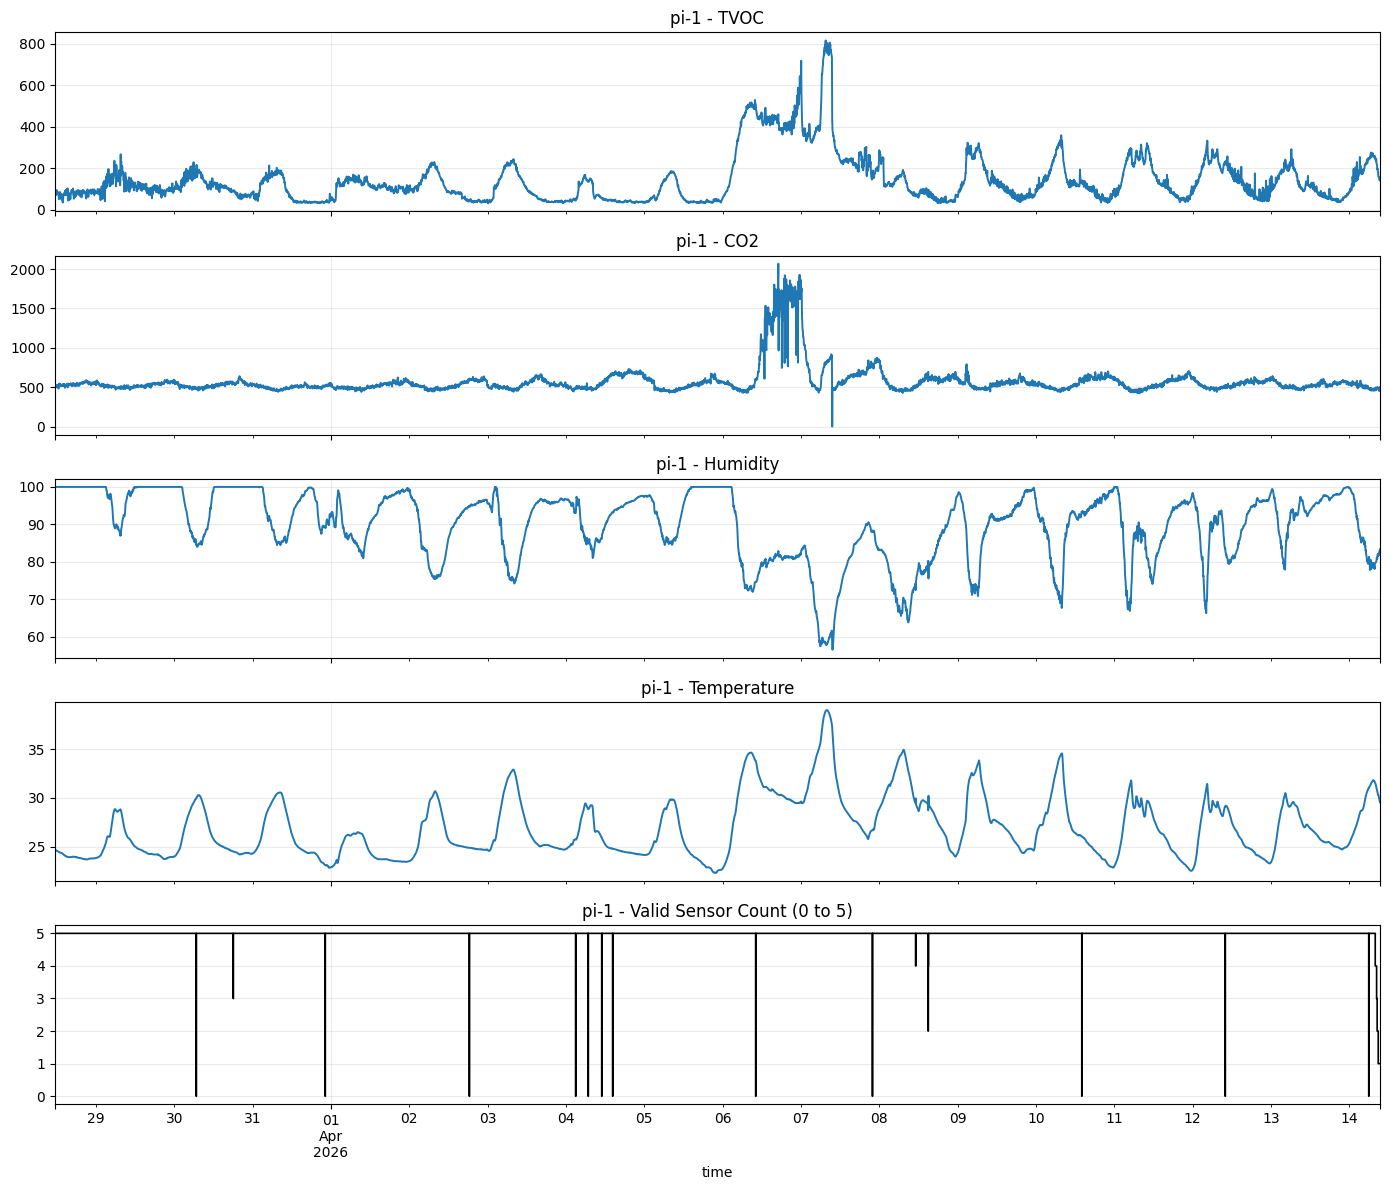

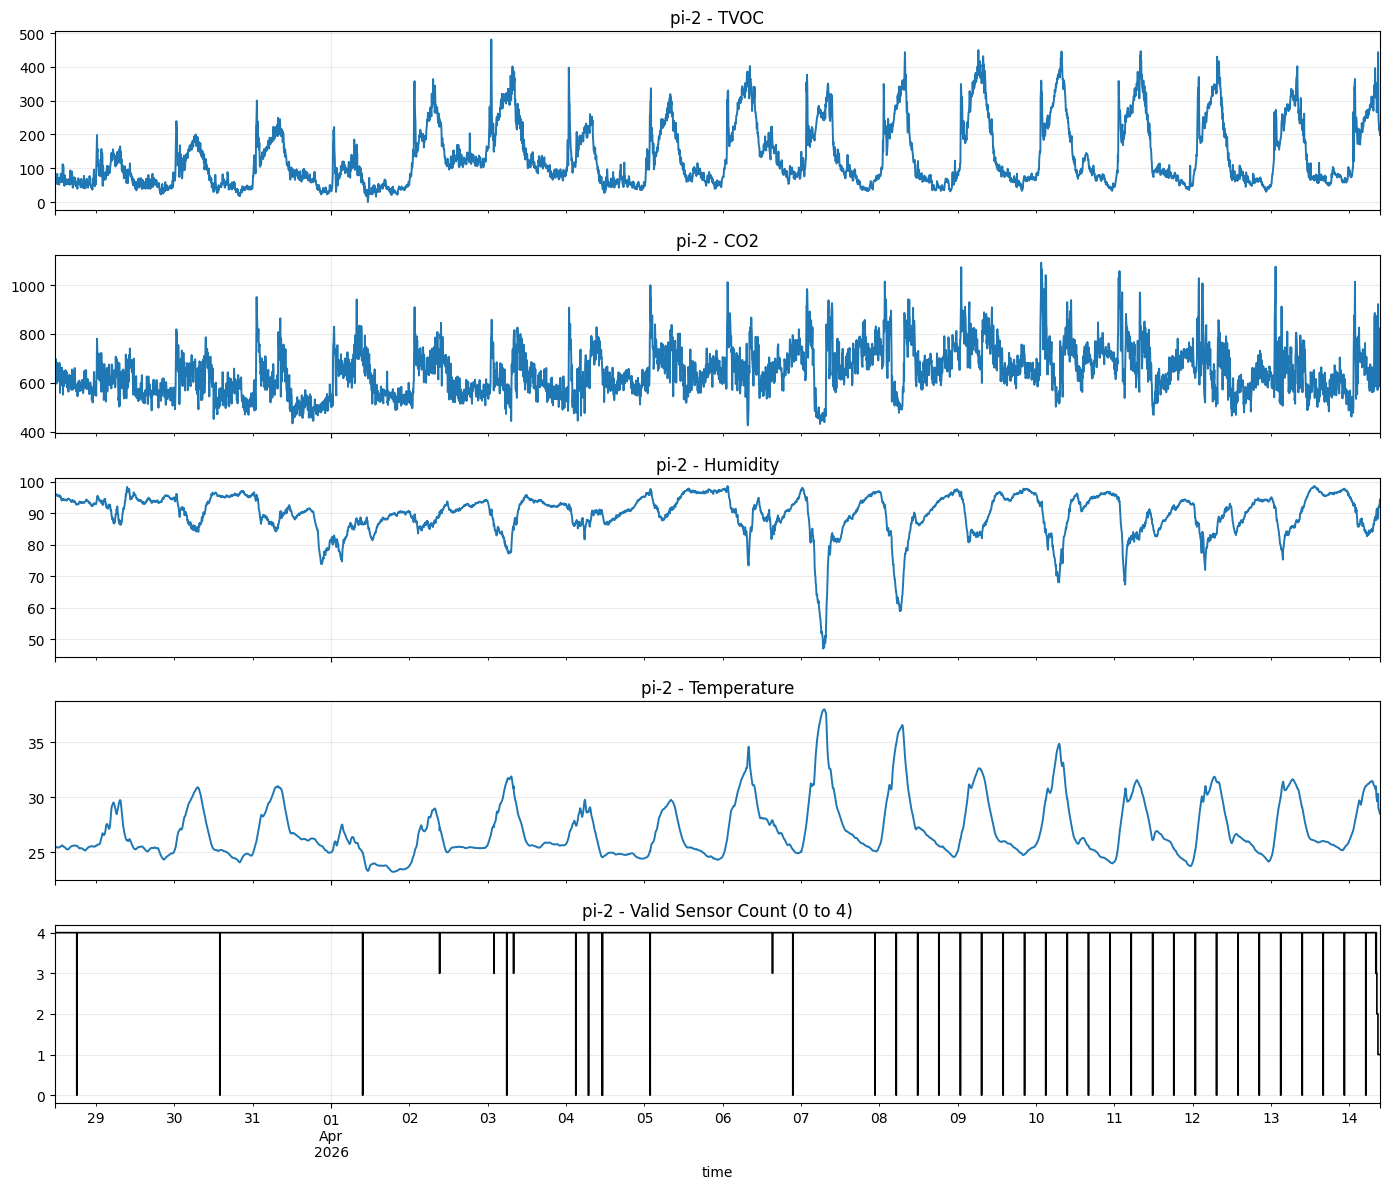

,input,output,rows_in,rows_5min,rows_with_le_2_sensors_working,dupe_timestamps_removed,delta_glitches_marked_total,rows_dropped_long_gaps,missing_after_fill_total
0,pi-1-data.csv,pi-1-data-clean-5min.csv,4861,4873,24,0,236,0,0
1,pi-2-data.csv,pi-2-data-clean-5min.csv,4838,4874,48,0,110,0,0


In [3]:
import matplotlib.pyplot as plt


def plot_cleaned_dataset(df: pd.DataFrame, title_prefix: str) -> None:
    plot_df = df.copy()
    plot_df["time"] = pd.to_datetime(plot_df["time"], utc=True)
    plot_df = plot_df.set_index("time")

    _, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

    for ax, col, label in [
        (axes[0], "tvoc", "TVOC"),
        (axes[1], "co2", "CO2"),
        (axes[2], "humidity", "Humidity"),
        (axes[3], "temp", "Temperature"),
    ]:
        if col in plot_df.columns:
            plot_df[col].plot(ax=ax, linewidth=1.4)
        ax.set_title(f"{title_prefix} - {label}")
        ax.grid(alpha=0.25)

    max_valid = (
        int(plot_df["valid_sensor_count"].max())
        if "valid_sensor_count" in plot_df.columns
        else 0
    )
    if "valid_sensor_count" in plot_df.columns:
        plot_df["valid_sensor_count"].plot(
            ax=axes[4], linewidth=1.2, color="black", drawstyle="steps-mid"
        )
    axes[4].set_title(f"{title_prefix} - Valid Sensor Count (0 to {max_valid})")
    axes[4].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


for input_name, cleaned_df in cleaned_frames.items():
    prefix = input_name.replace("-data.csv", "").replace(".csv", "")
    plot_cleaned_dataset(cleaned_df, title_prefix=prefix)

clean_report_df

## 3. Build Mechanistic Simulator and Scenario Checks

Define spray-action dynamics and validate behavior with fixed/random test cases.

This section generates compact scenario plots (including TVOC, CO2, temperature, RH, and action schedules).


In [47]:
from dataclasses import dataclass, field

import numpy as np
import pandas as pd


ACTION_DOSES: tuple[int, ...] = (0, 500, 1000, 1500)


@dataclass(frozen=True)
class RewardWeights:
    tvoc_excess_scale: float = 1.0

    tvoc_progress_scale: float = 1.0
    thi_scale: float = 0.25
    rh_excess_scale: float = 0.20
    cold_scale: float = 0.50
    action_scale: float = 0.05

    rh_target: float = 90.0
    use_tvoc_delta: bool = True


@dataclass
class Pi1SimulatorConfig:
    # Farm baseline dynamics
    baseline_decay: float = 0.20  # Used for emission recovery from real data

    # Rate at which spray physically settles or is blown out (e.g., 20% loss per 5-min)
    spray_settle_rate: float = 0.20

    # Second-order kinetic reaction constant: How fast Spray + TVOC neutralize
    # Tuned to approximate the previous 50% drop at 1000 dose
    k_react: float = 0.0005

    # Psychrometric constants: effect of 1 mg/L spray on RH and Temp
    k_humid: float = 0.05  # RH % increase per mg/L of spray
    k_cool: float = 0.8  # Temp °C drop per mg/L of spray (evaporative cooling)
    rh_beta: float = (
        0.001  # Nonlinearity for humidification effect (saturation at higher doses)
    )
    temp_alpha: float = (
        0.001  # Nonlinearity for cooling effect (saturation at higher doses)
    )
    # ------------------------------------------

    # Environment Bounds
    rh_min: float = 40.0
    rh_max: float = 100.0

    # Noise scales
    tvoc_noise_sigma: float = 1.0
    rh_noise_sigma: float = 0.1
    co2_noise_sigma: float = 15.0
    temp_noise_sigma: float = 0.2

    reward: RewardWeights = field(default_factory=RewardWeights)


def wetbulb_stull(temp_c: float, rh: float) -> float:
    """https://industrialmonitordirect.com/blogs/knowledgebase/wet-bulb-temperature-calculation-for-industrial-hvac-systems"""
    return (
        temp_c * np.arctan(0.151977 * np.sqrt(rh + 8.313659))
        + np.arctan(temp_c + rh)
        - np.arctan(rh - 1.676331)
        + 0.00391838 * rh**1.5 * np.arctan(0.023101 * rh)
        - 4.686035
    )


class Pi1SpraySimulator:
    """Mechanistic simulator for RL prototyping on pi-1 5-minute data."""

    def __init__(
        self,
        pi1_df: pd.DataFrame,
        config: Pi1SimulatorConfig | None = None,
        seed: int = 7,
    ) -> None:
        self.cfg = config or Pi1SimulatorConfig()
        self.rng = np.random.default_rng(seed)

        required_cols = ["tvoc", "co2", "temp", "humidity"]
        base = pi1_df.copy()
        for col in required_cols:
            base[col] = pd.to_numeric(base[col], errors="coerce")
        base = base.dropna(subset=required_cols).reset_index(drop=True)

        self.real_tvoc = base["tvoc"].to_numpy(dtype=float)
        self.real_co2 = base["co2"].to_numpy(dtype=float)
        self.real_temp = base["temp"].to_numpy(dtype=float)
        self.real_rh = base["humidity"].to_numpy(dtype=float)
        self.T = len(base)

        # Inverse Box Model: Recover latent emissions from real data
        self.emission = np.empty(self.T, dtype=float)
        self.emission[:-1] = (
            self.real_tvoc[1:]
            - self.real_tvoc[:-1]
            + self.cfg.baseline_decay * self.real_tvoc[:-1]
        )
        self.emission[-1] = self.emission[-2]

        # Latent state: Concentration of active spray currently suspended in the air
        self.active_spray_conc: float = 0.0

    @staticmethod
    def action_space() -> list[int]:
        return list(ACTION_DOSES)

    def reset(self, t0: int = 0) -> np.ndarray:
        self.active_spray_conc = 0.0
        t0 = int(np.clip(t0, 0, self.T - 1))
        return np.array(
            [
                self.real_tvoc[t0],
                self.real_co2[t0],
                self.real_temp[t0],
                self.real_rh[t0],
            ],
            dtype=float,
        )

    def step(self, state: np.ndarray, action: int, t: int) -> np.ndarray:
        t = int(np.clip(t, 0, self.T - 2))
        tvoc_current = float(state[0])

        # 1. Add new spray dose to the room
        self.active_spray_conc += action
        self.active_spray_conc = min(self.active_spray_conc, 2000)

        # 2. TVOC Kinetics (Bimolecular Reaction)
        # The amount of TVOC neutralized is proportional to [TVOC] * [Spray]
        reaction_rate = self.cfg.k_react * tvoc_current * self.active_spray_conc

        # We cannot react more TVOC than actually exists
        tvoc_removed = min(tvoc_current, reaction_rate)

        # Base mass balance: (Current - Removed) undergoes natural decay, plus new emissions
        tvoc_next = (tvoc_current - tvoc_removed) * (
            1.0 - self.cfg.baseline_decay
        ) + self.emission[t]
        tvoc_next = max(
            0.0, tvoc_next + self.rng.normal(0.0, self.cfg.tvoc_noise_sigma)
        )

        # 3. Psychrometrics (Evaporative Cooling & Humidification)
        # Apply deltas to the REAL baseline to isolate the spray's effect
        rh_base = self.real_rh[t + 1]
        temp_base = self.real_temp[t + 1]

        # Humidity (Nonlinear Saturation)
        rh_capacity = 100.0 - rh_base
        # Nonlinear saturation effect https://ingener.by/hvac-fundamentals/psychrometrics/psychrometric-processes/humidification/
        humid_eff = 1 - np.exp(-self.cfg.rh_beta * self.active_spray_conc)

        delta_rh = humid_eff * rh_capacity
        rh_next = rh_base + delta_rh

        # Temperature (Evaporative Cooling)
        wetbulb = wetbulb_stull(temp_base, rh_base)

        cooling_eff = 1 - np.exp(-self.cfg.temp_alpha * self.active_spray_conc)

        max_cooling = temp_base - wetbulb

        delta_T = cooling_eff * max_cooling
        temp_next = temp_base - delta_T

        temp_next = max(temp_next, wetbulb)

        # 4. CO2 tracks baseline (no abiotic interaction with spray)
        co2_next = self.real_co2[t + 1] + self.rng.normal(0.0, self.cfg.co2_noise_sigma)

        # 5. Spray Decay (Ventilation and Settling)
        self.active_spray_conc *= 1.0 - self.cfg.spray_settle_rate

        return np.array([tvoc_next, co2_next, temp_next, rh_next], dtype=float)

    def rollout(self, actions: list[int], t0: int = 0) -> pd.DataFrame:
        """Run one trajectory and return a DataFrame for quick inspection."""
        t = int(np.clip(t0, 0, self.T - 2))
        state = self.reset(t)

        rows: list[dict[str, float | int]] = [
            {
                "t": t,
                "action": -1,
                "tvoc": state[0],
                "co2": state[1],
                "temp": state[2],
                "rh": state[3],
            }
        ]

        for a in actions:
            next_state = self.step(state, int(a), t)
            t += 1
            rows.append(
                {
                    "t": t,
                    "action": int(a),
                    "tvoc": next_state[0],
                    "co2": next_state[1],
                    "temp": next_state[2],
                    "rh": next_state[3],
                }
            )
            state = next_state

            if t >= self.T - 2:
                break

        return pd.DataFrame(rows)

    def compute_reward(
        self,
        tvoc_prev: float,
        tvoc_next: float,
        rh_next: float,
        temp_next: float,
        action: int,
        reward_weights: RewardWeights | None = None,
        rh_baseline: float | None = None,
        temp_baseline: float | None = None,
    ) -> float:
        w = reward_weights or self.cfg.reward

        # ---- 1) TVOC: reward progress, penalize remaining excess ----
        safe_tvoc_threshold = 50.0

        # Progress signal: positive if TVOC went down, negative if it went up.
        tvoc_delta = tvoc_prev - tvoc_next
        tvoc_progress_term = 0.0
        if w.use_tvoc_delta:
            tvoc_progress_term = w.tvoc_progress_scale * np.clip(
                tvoc_delta / 50.0, -2.0, 2.0
            )

        # Remaining excess above the safe threshold.
        tvoc_excess = max(0.0, tvoc_next - safe_tvoc_threshold) / 50.0
        tvoc_excess_term = -w.tvoc_excess_scale * tvoc_excess

        # ---- 2) THI: penalize only if worse than baseline and above stress threshold ----
        base_t = temp_baseline if temp_baseline is not None else temp_next
        base_rh = rh_baseline if rh_baseline is not None else rh_next

        baseline_thi = (0.8 * base_t) + ((base_rh / 100.0) * (base_t - 14.4)) + 46.4
        current_thi = (
            (0.8 * temp_next) + ((rh_next / 100.0) * (temp_next - 14.4)) + 46.4
        )

        # Mild heat stress for most livestock begins around THI 72
        safe_thi_threshold = max(72.0, baseline_thi)
        thi_excess = max(0.0, current_thi - safe_thi_threshold) / 5.0
        thi_term = -w.thi_scale * thi_excess

        # ---- 3) Absolute RH penalty: normalized excess above target ----
        rh_excess = max(0.0, rh_next - w.rh_target) / 10.0
        rh_term = -w.rh_excess_scale * rh_excess

        # ---- 4) Cold stress penalty: normalized degrees below minimum ----
        # Below 18°C can be detrimental depending on the livestock age/type.
        # We penalize linearly with a soft saturation to avoid extreme penalties for large overshoots.
        safe_temp_min = 18.0
        cold_excess = max(0.0, safe_temp_min - temp_next) / 2.0
        cold_term = -w.cold_scale * cold_excess

        # ---- 5) Action penalty: normalize by max dose so it stays small ----
        action_term = -w.action_scale * (float(action) / 1500.0)

        reward = (
            tvoc_progress_term
            + tvoc_excess_term
            + thi_term
            + rh_term
            + cold_term
            + action_term
        )
        return float(reward)

Simulator initialized: T=4873 steps, action_space=[0, 500, 1000, 1500]


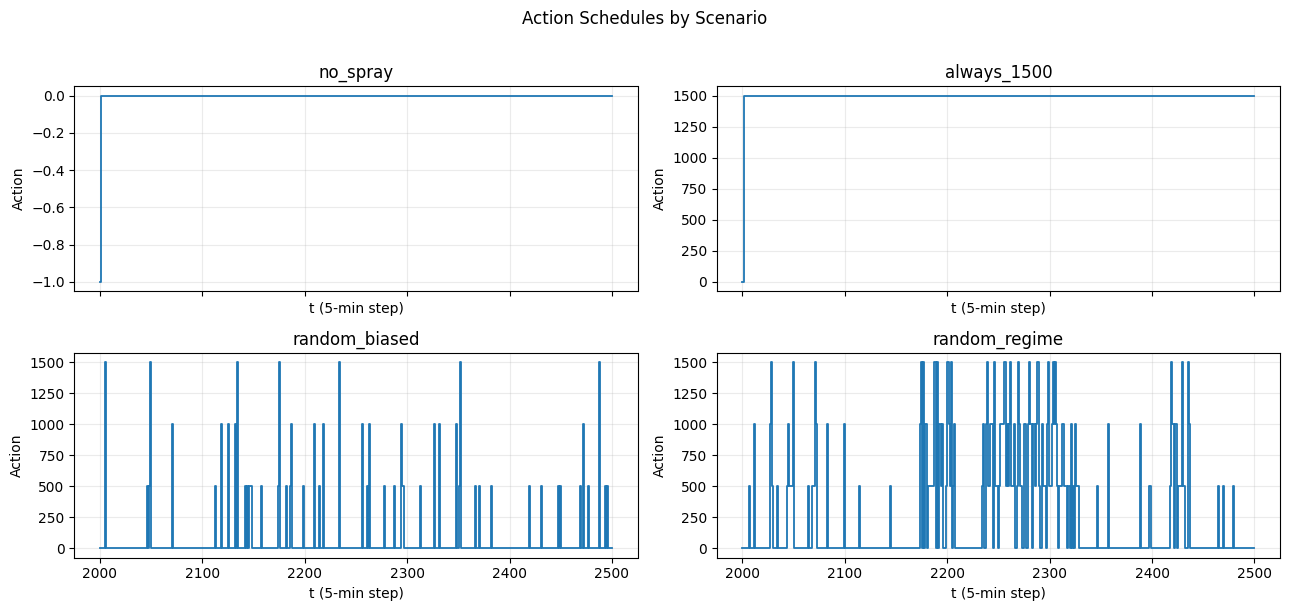

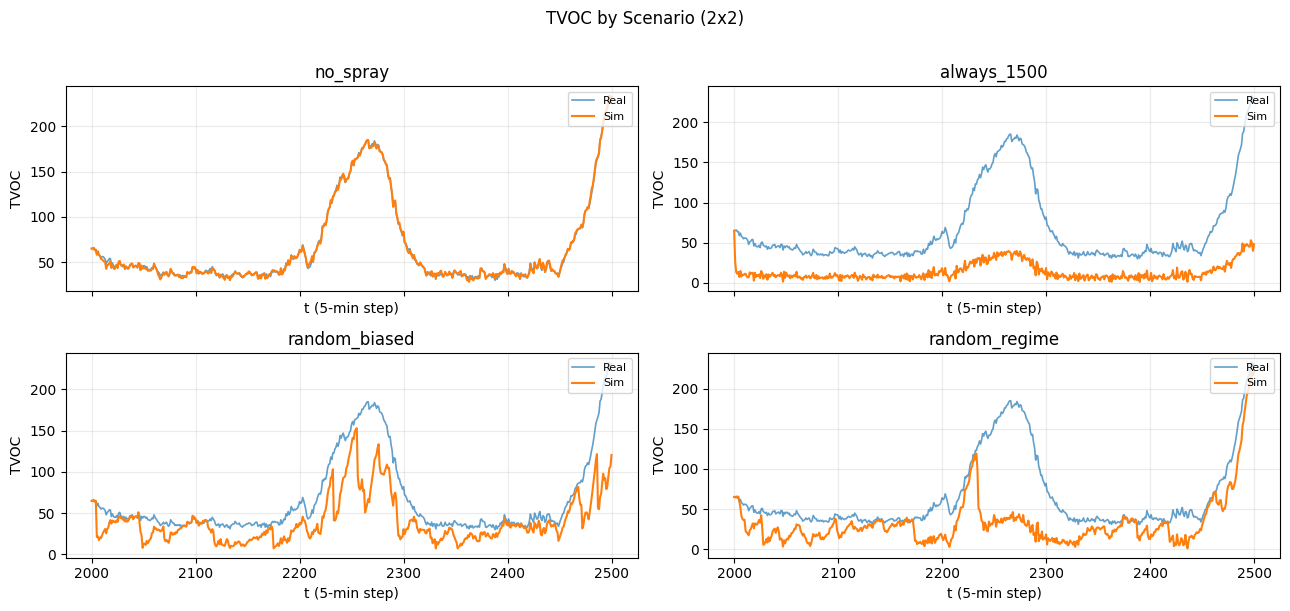

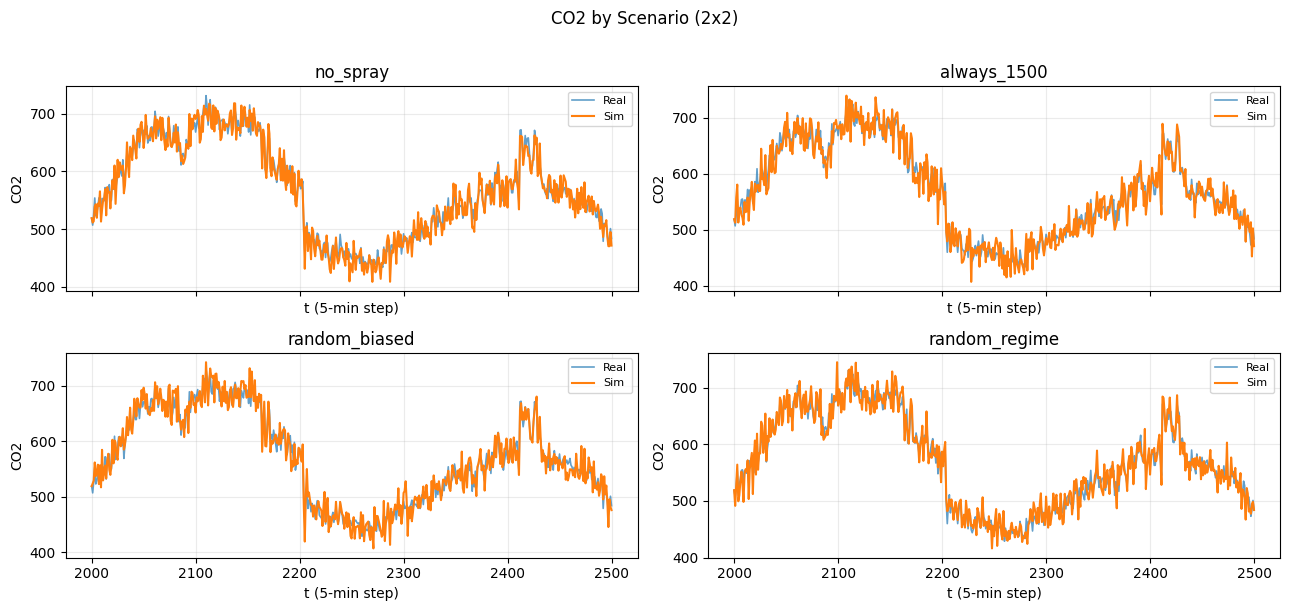

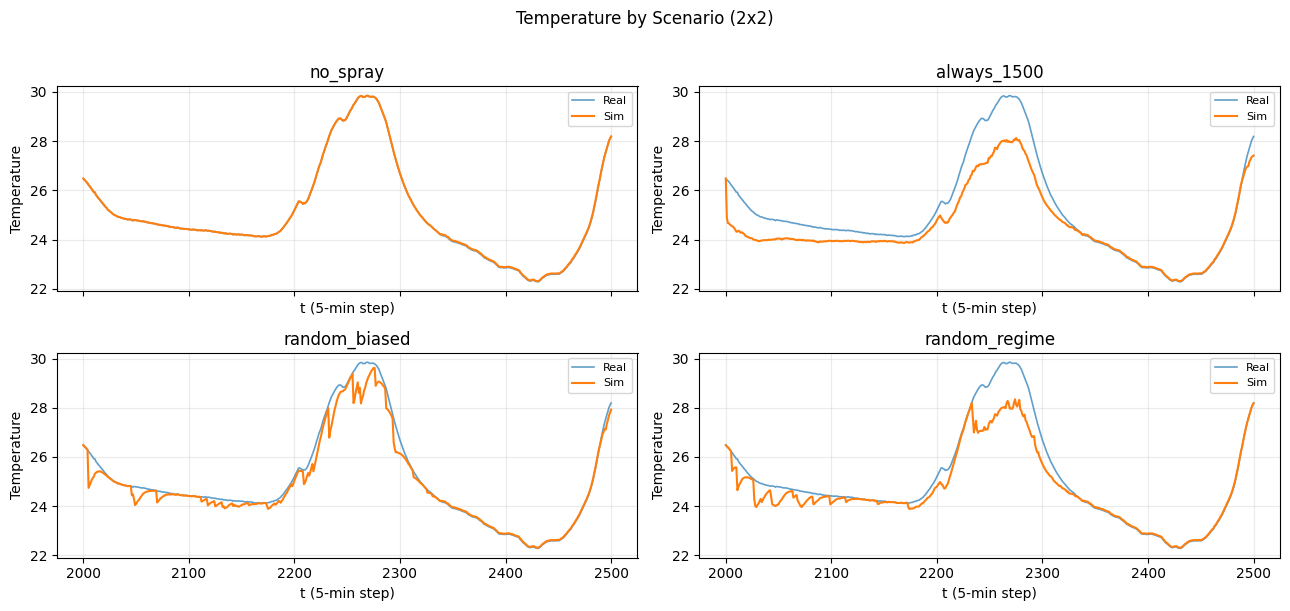

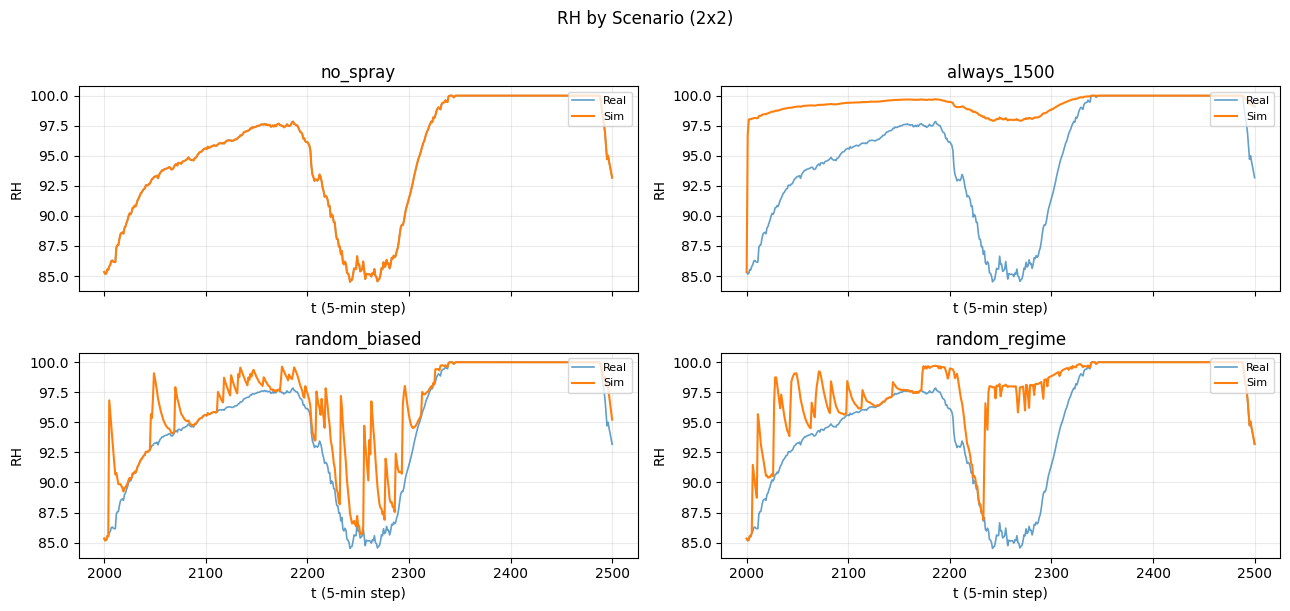

,case,steps,tvoc_start,tvoc_end,tvoc_change,tvoc_mae_vs_real,rh_start,rh_end,rh_change,tvoc_min,tvoc_max
0,no_spray,500,65.0,232.881222,167.881222,1.181389,85.34,93.180000,7.840000,28.235168,233.931834
1,always_1500,500,65.0,48.143985,-16.856015,52.545081,85.34,99.077013,13.737013,1.436466,65.000000
2,random_biased,500,65.0,120.470555,55.470555,25.941983,85.34,95.225410,9.885410,7.262233,153.001613
3,random_regime,500,65.0,221.031547,156.031547,33.170235,85.34,93.215849,7.875849,1.008500,221.031547


In [48]:
if "plt" not in globals():
    import matplotlib.pyplot as plt

# Shared simulator/scenario defaults for reproducible quick checks.
SIM_INPUT_FILE = "pi-1-data-clean-5min.csv"
CASE_SUITE: list[str] = ["no_spray", "always_1500", "random_biased", "random_regime"]
CASE_RUN_STEPS = 500
CASE_RUN_T0 = 2000
CASE_RNG_SEED = 17

# Build simulator from pi-1 only.
base_dir = Path.cwd()
if "cleaned_frames" in globals() and "pi-1-data.csv" in cleaned_frames:
    pi1_df = cleaned_frames["pi-1-data.csv"].copy()
else:
    pi1_df = pd.read_csv(base_dir / SIM_INPUT_FILE)

sim = Pi1SpraySimulator(pi1_df)
print(f"Simulator initialized: T={sim.T} steps, action_space={sim.action_space()}")


def _safe_horizon(simulator: Pi1SpraySimulator, requested_steps: int) -> int:
    """Clamp rollout length to available replay horizon."""
    return max(2, min(int(requested_steps), simulator.T - 2))


def make_action_plan(
    case: str,
    steps: int,
    rng: np.random.Generator | None = None,
) -> list[int]:
    """Build categorical action sequence for scenario testing."""
    case_key = case.strip().lower()
    local_rng = rng if rng is not None else np.random.default_rng(CASE_RNG_SEED)

    if case_key in {"no_spray", "none", "case1"}:
        return [0] * steps

    if case_key in {"always_1500", "max", "case2"}:
        return [1500] * steps

    if case_key in {"random_biased", "random", "rare_spray", "case3"}:
        # No spray is dominant; higher doses are progressively rarer.
        actions = np.array(ACTION_DOSES, dtype=int)
        probs = np.array([0.90, 0.06, 0.03, 0.01], dtype=float)
        sampled = local_rng.choice(actions, size=steps, replace=True, p=probs)
        return sampled.tolist()

    if case_key in {"random_regime", "regime_switch", "bursty", "case4"}:
        # Regime-switching policy: long sparse periods and occasional bursty periods.
        actions = np.array(ACTION_DOSES, dtype=int)
        low_probs = np.array([0.96, 0.03, 0.009, 0.001], dtype=float)
        high_probs = np.array([0.20, 0.30, 0.30, 0.20], dtype=float)

        # Persistence creates contiguous periods in each regime.
        p_stay_low = 0.97
        p_stay_high = 0.93
        in_high_regime = bool(local_rng.random() < 0.15)

        sampled_actions: list[int] = []
        for _ in range(steps):
            if in_high_regime:
                sampled_actions.append(int(local_rng.choice(actions, p=high_probs)))
                if local_rng.random() > p_stay_high:
                    in_high_regime = False
            else:
                sampled_actions.append(int(local_rng.choice(actions, p=low_probs)))
                if local_rng.random() > p_stay_low:
                    in_high_regime = True

        return sampled_actions

    raise ValueError(
        "Unknown case. Use one of: no_spray, always_1500, random_biased, random_regime."
    )


def run_case(
    simulator: Pi1SpraySimulator,
    case: str,
    steps: int = 300,
    t0: int = 0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Run one test case and return (simulated, real_reference) DataFrames."""
    safe_steps = _safe_horizon(simulator, steps)
    t0 = int(np.clip(t0, 0, simulator.T - safe_steps - 1))

    actions = make_action_plan(case, safe_steps, rng=simulator.rng)
    sim_df = simulator.rollout(actions, t0=t0).copy()

    real_slice = pd.DataFrame(
        {
            "t": np.arange(t0, t0 + safe_steps + 1),
            "tvoc_real": simulator.real_tvoc[t0 : t0 + safe_steps + 1],
            "co2_real": simulator.real_co2[t0 : t0 + safe_steps + 1],
            "temp_real": simulator.real_temp[t0 : t0 + safe_steps + 1],
            "rh_real": simulator.real_rh[t0 : t0 + safe_steps + 1],
        }
    )

    return sim_df, real_slice


def summarize_case(
    sim_df: pd.DataFrame, real_df: pd.DataFrame, case: str
) -> pd.DataFrame:
    """Compact metrics to support quick tuning iterations."""
    tvoc_start = float(sim_df["tvoc"].iloc[0])
    tvoc_end = float(sim_df["tvoc"].iloc[-1])
    rh_start = float(sim_df["rh"].iloc[0])
    rh_end = float(sim_df["rh"].iloc[-1])

    merged = sim_df.merge(real_df[["t", "tvoc_real"]], on="t", how="left")
    tvoc_mae = float((merged["tvoc"] - merged["tvoc_real"]).abs().mean())

    return pd.DataFrame(
        [
            {
                "case": case,
                "steps": int(len(sim_df) - 1),
                "tvoc_start": tvoc_start,
                "tvoc_end": tvoc_end,
                "tvoc_change": tvoc_end - tvoc_start,
                "tvoc_mae_vs_real": tvoc_mae,
                "rh_start": rh_start,
                "rh_end": rh_end,
                "rh_change": rh_end - rh_start,
                "tvoc_min": float(sim_df["tvoc"].min()),
                "tvoc_max": float(sim_df["tvoc"].max()),
            }
        ]
    )


def _scenario_grid(n_cases: int) -> tuple[int, int]:
    cols = 2
    rows = int(np.ceil(n_cases / cols))
    return rows, cols


def plot_metric_case_grid(
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]],
    sim_col: str,
    real_col: str,
    y_label: str,
    title: str,
) -> None:
    """Plot one metric across all cases in a compact 2-column grid."""
    cases = list(case_runs.keys())
    rows, cols = _scenario_grid(len(cases))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 3.0 * rows), sharex=True)
    axes_flat = np.atleast_1d(axes).ravel()

    for i, case in enumerate(cases):
        ax = axes_flat[i]
        sim_df, real_df = case_runs[case]
        ax.plot(real_df["t"], real_df[real_col], label="Real", alpha=0.7, linewidth=1.2)
        ax.plot(sim_df["t"], sim_df[sim_col], label="Sim", linewidth=1.5)
        ax.set_title(case)
        ax.set_ylabel(y_label)
        ax.grid(alpha=0.25)
        ax.legend(loc="upper right", fontsize=8)

    for j in range(len(cases), len(axes_flat)):
        axes_flat[j].set_visible(False)

    for ax in axes_flat[: len(cases)]:
        ax.set_xlabel("t (5-min step)")

    fig.suptitle(title, fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()


def plot_action_case_grid(
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]],
) -> None:
    """Plot action schedules across all cases in a compact 2-column grid."""
    cases = list(case_runs.keys())
    rows, cols = _scenario_grid(len(cases))
    fig, axes = plt.subplots(rows, cols, figsize=(13, 3.0 * rows), sharex=True)
    axes_flat = np.atleast_1d(axes).ravel()

    for i, case in enumerate(cases):
        ax = axes_flat[i]
        sim_df, _ = case_runs[case]
        ax.step(sim_df["t"], sim_df["action"], where="post", linewidth=1.3)
        ax.set_title(case)
        ax.set_ylabel("Action")
        ax.grid(alpha=0.25)

    for j in range(len(cases), len(axes_flat)):
        axes_flat[j].set_visible(False)

    for ax in axes_flat[: len(cases)]:
        ax.set_xlabel("t (5-min step)")

    fig.suptitle("Action Schedules by Scenario", fontsize=12, y=1.01)
    fig.tight_layout()
    plt.show()


def run_three_case_suite(
    simulator: Pi1SpraySimulator,
    steps: int = 288,
    t0: int = 0,
    plot: bool = True,
) -> tuple[dict[str, pd.DataFrame], pd.DataFrame]:
    """Run case scenarios and return trajectories + summary metrics."""
    trajectories: dict[str, pd.DataFrame] = {}
    summary_frames: list[pd.DataFrame] = []
    case_runs: dict[str, tuple[pd.DataFrame, pd.DataFrame]] = {}

    for case in CASE_SUITE:
        sim_df, real_df = run_case(simulator, case=case, steps=steps, t0=t0)
        trajectories[case] = sim_df
        case_runs[case] = (sim_df, real_df)
        summary_frames.append(summarize_case(sim_df, real_df, case))

    if plot:
        plot_action_case_grid(case_runs)

        plot_metric_case_grid(
            case_runs,
            sim_col="tvoc",
            real_col="tvoc_real",
            y_label="TVOC",
            title="TVOC by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="co2",
            real_col="co2_real",
            y_label="CO2",
            title="CO2 by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="temp",
            real_col="temp_real",
            y_label="Temperature",
            title="Temperature by Scenario (2x2)",
        )
        plot_metric_case_grid(
            case_runs,
            sim_col="rh",
            real_col="rh_real",
            y_label="RH",
            title="RH by Scenario (2x2)",
        )

    summary_df = pd.concat(summary_frames, ignore_index=True)
    return trajectories, summary_df


# Execute default long-horizon checks.
case_trajectories, case_summary_df = run_three_case_suite(
    sim, steps=CASE_RUN_STEPS, t0=CASE_RUN_T0, plot=True
)
case_summary_df

## 4. Define the Gymnasium RL Environment

Wrap the simulator as an RL environment with normalized observations, discrete actions, and custom reward shaping.


In [49]:
from dataclasses import dataclass, field

import gymnasium as gym
from gymnasium import spaces


@dataclass(frozen=True)
class EnvConfig:
    reward: RewardWeights = field(default_factory=RewardWeights)
    max_steps: int = 250
    delta_reward_scale: float = 0.4
    tvoc_norm_divisor: float = 500.0
    co2_norm_divisor: float = 2000.0
    temp_norm_divisor: float = 40.0
    rh_min: float = 40.0
    rh_span: float = 60.0


DEFAULT_ENV_CONFIG = EnvConfig(
    reward=RewardWeights(
        tvoc_excess_scale=1.0,
        tvoc_progress_scale=1.2,
        thi_scale=0.25,
        rh_excess_scale=0.20,
        cold_scale=0.50,
        action_scale=0.05,
        use_tvoc_delta=True,
    )
)


class Pi1SprayEnv(gym.Env):
    """Gymnasium-compliant environment for deodorization spray control."""

    metadata = {"render_modes": []}

    def __init__(
        self,
        simulator: Pi1SpraySimulator,
        config: EnvConfig | None = None,
    ) -> None:
        self.sim = simulator
        self.cfg = config or DEFAULT_ENV_CONFIG

        # Action space: categorical [0, 500, 1000, 1500]
        self.action_to_dose = {idx: dose for idx, dose in enumerate(ACTION_DOSES)}
        self.action_space = spaces.Discrete(len(self.action_to_dose))

        # Observation: [tvoc_norm, co2_norm, temp_norm, rh_norm, d_tvoc_norm, d_rh_norm]
        self.observation_space = spaces.Box(
            low=np.array([0.0, 0.0, 0.0, 0.0, -1.0, -1.0], dtype=np.float32),
            high=np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32),
            dtype=np.float32,
        )

        self.state: np.ndarray = np.zeros(4, dtype=np.float32)
        self.prev_state: np.ndarray = np.zeros(4, dtype=np.float32)
        self.t: int = 0
        self.t_start: int = 0
        self.steps_taken: int = 0

    def reset(
        self, seed: int | None = None, options: dict | None = None
    ) -> tuple[np.ndarray, dict]:
        super().reset(seed=seed)
        _ = options
        self.t_start = self.np_random.integers(
            0, max(1, self.sim.T - self.cfg.max_steps)
        )
        self.t = self.t_start
        self.state = self.sim.reset(t0=self.t_start).astype(np.float32)
        self.prev_state = self.state.copy()
        self.steps_taken = 0

        obs = self._build_obs(self.state, d_tvoc_norm=0.0, d_rh_norm=0.0)
        return obs, {}

    def step(self, action: int) -> tuple[np.ndarray, float, bool, bool, dict]:
        dose = self.action_to_dose[int(action)]
        state_prev = self.state.copy()
        next_state = self.sim.step(state_prev, dose, self.t).astype(np.float32)

        d_tvoc_norm = float(np.clip((next_state[0] - state_prev[0]) / 500.0, -1.0, 1.0))
        d_rh_norm = float(np.clip((next_state[3] - state_prev[3]) / 60.0, -1.0, 1.0))

        # Retrieve the real baseline RH for the current step
        current_real_rh = float(self.sim.real_rh[self.t])
        current_real_temp = float(self.sim.real_temp[self.t])

        reward = self.sim.compute_reward(
            tvoc_prev=float(state_prev[0]),
            tvoc_next=float(next_state[0]),
            rh_next=float(next_state[3]),
            temp_next=float(next_state[2]),
            action=dose,
            reward_weights=self.cfg.reward,
            rh_baseline=current_real_rh,  # Pass real RH to avoid unfair penalties
            temp_baseline=current_real_temp,  # Same for temperature
        )

        self.prev_state = state_prev
        self.state = next_state
        self.t += 1
        self.steps_taken += 1

        terminated = self.t >= self.sim.T - 2
        truncated = self.steps_taken >= self.cfg.max_steps

        info = {
            "tvoc": float(self.state[0]),
            "rh": float(self.state[3]),
            "dose": dose,
            "d_tvoc_norm": d_tvoc_norm,
            "d_rh_norm": d_rh_norm,
        }

        obs = self._build_obs(self.state, d_tvoc_norm=d_tvoc_norm, d_rh_norm=d_rh_norm)
        return obs, reward, terminated, truncated, info

    def _build_obs(
        self, s: np.ndarray, d_tvoc_norm: float, d_rh_norm: float
    ) -> np.ndarray:
        base = np.array(
            [
                s[0] / self.cfg.tvoc_norm_divisor,
                s[1] / self.cfg.co2_norm_divisor,
                s[2] / self.cfg.temp_norm_divisor,
                (s[3] - self.cfg.rh_min) / self.cfg.rh_span,
            ],
            dtype=np.float32,
        )
        delta = np.array([d_tvoc_norm, d_rh_norm], dtype=np.float32)
        return np.concatenate([base, delta], axis=0)


# Instantiate environment
env = Pi1SprayEnv(sim, config=DEFAULT_ENV_CONFIG)
print(
    f"Environment created: action_space={env.action_space}, obs_space={env.observation_space}"
)
print(f"Action mapping: {env.action_to_dose}")

Environment created: action_space=Discrete(4), obs_space=Box([ 0.  0.  0.  0. -1. -1.], 1.0, (6,), float32)
Action mapping: {0: 0, 1: 500, 2: 1000, 3: 1500}


## 5. Train a PPO Baseline Policy

Train a first policy on the simulator and run a quick deterministic rollout.

> Tip:
> Rerun this section after reward or dynamics changes to compare policy behavior consistently.


In [50]:
import os
import time
from dataclasses import dataclass

# Force CPU to avoid ROCm kernel crashes on unsupported gfx targets.
os.environ["CUDA_VISIBLE_DEVICES"] = ""

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env


@dataclass(frozen=True)
class PPOTrainConfig:
    n_envs: int = 4
    n_steps: int = 128
    total_timesteps: int = 50_000
    learning_rate: float = 3e-4
    batch_size: int = 64
    n_epochs: int = 10
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_range: float = 0.2
    device: str = "cpu"


TRAIN_CONFIG = PPOTrainConfig()

if "sim" not in globals():
    raise RuntimeError(
        "Simulator `sim` is not defined. Re-run cells 2 through 7 in order after a kernel restart."
    )


def make_env(simulator: Pi1SpraySimulator, config: EnvConfig) -> Pi1SprayEnv:
    return Pi1SprayEnv(simulator, config=config)


# Vectorized env for faster sampling in notebook-safe mode (DummyVecEnv).
vec_env = make_vec_env(
    lambda: make_env(sim, DEFAULT_ENV_CONFIG),
    n_envs=TRAIN_CONFIG.n_envs,
)

# Train PPO baseline.
print(f"Initializing PPO agent on CPU with VecEnv (n_envs={TRAIN_CONFIG.n_envs})...")
model = PPO(
    "MlpPolicy",
    vec_env,
    learning_rate=TRAIN_CONFIG.learning_rate,
    n_steps=TRAIN_CONFIG.n_steps,
    batch_size=TRAIN_CONFIG.batch_size,
    n_epochs=TRAIN_CONFIG.n_epochs,
    gamma=TRAIN_CONFIG.gamma,
    gae_lambda=TRAIN_CONFIG.gae_lambda,
    clip_range=TRAIN_CONFIG.clip_range,
    device=TRAIN_CONFIG.device,
    verbose=1,
)

print(f"\nTraining for {TRAIN_CONFIG.total_timesteps:,} steps...")
start_train = time.time()
model.learn(total_timesteps=TRAIN_CONFIG.total_timesteps, log_interval=10)
elapsed = time.time() - start_train
print(f"Training completed in {elapsed:.1f}s.")

# Save model
model.save("/tmp/ppo_spray_baseline")
print("Model saved to /tmp/ppo_spray_baseline")

# Quick eval on a single non-vectorized env for readable episode metrics.
eval_env = make_env(sim, DEFAULT_ENV_CONFIG)

print("\nEvaluation Rollout")
obs, _ = eval_env.reset(seed=42)
episode_reward = 0.0
episode_steps = 0
episode_tvoc_init = float(obs[0])
episode_rh_init = float(obs[3])

for _ in range(500):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = eval_env.step(int(action))
    episode_reward += reward
    episode_steps += 1
    if terminated or truncated:
        break

print(f"Episode length: {episode_steps} steps")
print(f"Episode cumulative reward: {episode_reward:.2f}")
print(f"Final TVOC: {info['tvoc']:.1f} (started at {episode_tvoc_init:.1f})")
print(f"Final RH: {info['rh']:.1f}% (started at {episode_rh_init:.1f}%)")

Initializing PPO agent on CPU with VecEnv (n_envs=4)...
Using cpu device

Training for 50,000 steps...
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 250           |
|    ep_rew_mean          | -90.8         |
| time/                   |               |
|    fps                  | 3665          |
|    iterations           | 10            |
|    time_elapsed         | 1             |
|    total_timesteps      | 5120          |
| train/                  |               |
|    approx_kl            | 0.00032092014 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    entropy_loss         | -1.24         |
|    explained_variance   | 0.0197        |
|    learning_rate        | 0.0003        |
|    loss                 | 22.2          |
|    n_updates            | 90            |
|    policy_gradient_loss | 0.00167       |
|    value_loss           | 53.2          |
-----------------

## 6. Evaluate Policy and Compare Training Budgets

Compute aggregate metrics over multiple episodes and benchmark policies trained with different timestep budgets.


In [51]:
from collections import Counter
from dataclasses import replace


def evaluate_trained_model(
    trained_model: PPO,
    simulator: Pi1SpraySimulator,
    env_config: EnvConfig,
    n_episodes: int = 20,
    max_steps: int = 250,
    seed: int = 42,
) -> pd.DataFrame:
    """Run deterministic evaluation and return aggregate metrics."""
    rewards: list[float] = []
    tvoc_delta: list[float] = []
    mean_rh_excess_per_episode: list[float] = []
    action_counter: Counter[int] = Counter()

    eval_cfg = replace(env_config, max_steps=max_steps)

    for ep in range(n_episodes):
        eval_env = Pi1SprayEnv(simulator, config=eval_cfg)
        obs, _ = eval_env.reset(seed=seed + ep)

        ep_reward = 0.0
        ep_rh_excess_values: list[float] = []
        tvoc_start = float(obs[0])

        while True:
            action, _ = trained_model.predict(obs, deterministic=True)
            action_int = int(action)
            obs, reward, terminated, truncated, info = eval_env.step(action_int)

            ep_reward += float(reward)
            action_counter[int(info["dose"])] += 1
            ep_rh_excess_values.append(
                max(0.0, float(info["rh"]) - env_config.reward.rh_target)
            )

            if terminated or truncated:
                break

        rewards.append(ep_reward)
        tvoc_delta.append(float(info["tvoc"]) - tvoc_start)
        mean_rh_excess_per_episode.append(float(np.mean(ep_rh_excess_values)))

    total_actions = sum(action_counter.values())
    action_ratio = {
        f"dose_{dose}_ratio": action_counter.get(dose, 0) / max(1, total_actions)
        for dose in ACTION_DOSES
    }

    out = {
        "episodes": n_episodes,
        "reward_mean": float(np.mean(rewards)),
        "reward_std": float(np.std(rewards)),
        "tvoc_delta_mean": float(np.mean(tvoc_delta)),
        "tvoc_delta_std": float(np.std(tvoc_delta)),
        "mean_rh_excess": float(np.mean(mean_rh_excess_per_episode)),
        **action_ratio,
    }
    return pd.DataFrame([out])


def train_and_evaluate_budget(
    simulator: Pi1SpraySimulator,
    env_config: EnvConfig,
    total_timesteps: int,
    n_envs: int = 4,
    n_steps: int = 128,
    eval_episodes: int = 20,
    seed: int = 42,
) -> pd.DataFrame:
    """Train a fresh model for a given budget, then evaluate it."""
    vec = make_vec_env(
        lambda: Pi1SprayEnv(simulator, config=env_config),
        n_envs=n_envs,
        seed=seed,
    )

    candidate = PPO(
        "MlpPolicy",
        vec,
        learning_rate=TRAIN_CONFIG.learning_rate,
        n_steps=n_steps,
        batch_size=TRAIN_CONFIG.batch_size,
        n_epochs=TRAIN_CONFIG.n_epochs,
        gamma=TRAIN_CONFIG.gamma,
        gae_lambda=TRAIN_CONFIG.gae_lambda,
        clip_range=TRAIN_CONFIG.clip_range,
        device=TRAIN_CONFIG.device,
        verbose=0,
        seed=seed,
    )
    candidate.learn(total_timesteps=total_timesteps)

    metrics = evaluate_trained_model(
        candidate,
        simulator,
        env_config=env_config,
        n_episodes=eval_episodes,
        max_steps=env_config.max_steps,
        seed=seed + 1000,
    )
    metrics["timesteps"] = int(total_timesteps)
    return metrics


# Example 1: Evaluate current model quality.
# current_eval_df = evaluate_trained_model(
#     model, sim, env_config=DEFAULT_ENV_CONFIG, n_episodes=20, max_steps=250, seed=123
# )
# current_eval_df

# Example 2: Compare training budgets (uncomment to run).
budgets = [50_000, 100_000, 200_000]
compare_df = pd.concat(
    [
        train_and_evaluate_budget(
            sim,
            env_config=DEFAULT_ENV_CONFIG,
            total_timesteps=b,
            n_envs=TRAIN_CONFIG.n_envs,
            n_steps=TRAIN_CONFIG.n_steps,
            eval_episodes=10,
        )
        for b in budgets
    ],
    ignore_index=True,
)
compare_df.sort_values("timesteps")

,episodes,reward_mean,reward_std,tvoc_delta_mean,tvoc_delta_std,mean_rh_excess,dose_0_ratio,dose_500_ratio,dose_1000_ratio,dose_1500_ratio,timesteps
0,10,-62.008970,5.759624,24.835734,18.750828,8.764789,0.0000,0.0,0.0000,1.0,50000
1,10,-54.870758,5.982156,24.808102,18.608209,8.736878,0.0000,1.0,0.0000,0.0,100000
2,10,-52.520532,12.699161,44.980899,12.120773,6.996644,0.7772,0.0,0.2228,0.0,200000


## 7. Demo Code for Online Update Loop with Real Data Feed

Only for showing what it would look like to adapt this approach to when real data will be available. By then, the agent and Gym environment will continuously collect transitions and periodically continue training.

Caution: this loop runs indefinitely (`while True`), and is not intended to be run.


In [131]:
import time
from collections import deque

import pandas as pd

POLL_INTERVAL_SEC = 10
LEARN_EVERY_SEC = 15 * 60
MIN_NEW_SAMPLES = 50
LEARN_TIMESTEPS = 10_000
REPLAY_MAXLEN = 50_000
ONLINE_N_ENVS = TRAIN_CONFIG.n_envs

if "model" not in globals():
    raise RuntimeError("`model` not found. Train/load PPO model first.")
if "env" not in globals():
    raise RuntimeError("`env` not found. Create Pi1SprayEnv first.")
if "sim" not in globals():
    raise RuntimeError("`sim` not found. Build simulator first.")

replay = deque(maxlen=REPLAY_MAXLEN)
samples_since_update = 0
last_learn_ts = time.time()

obs, _ = env.reset(seed=123)


def poll_latest_real_transition(current_obs: np.ndarray):
    time.sleep(POLL_INTERVAL_SEC)
    action, _ = model.predict(current_obs, deterministic=True)
    next_obs, reward, terminated, truncated, info = env.step(int(action))
    done = bool(terminated or truncated)
    return int(action), next_obs, float(reward), done, info


def build_latest_training_env():
    """Factory stub for training env built from newest real data window."""
    return make_vec_env(
        lambda: Pi1SprayEnv(sim, config=DEFAULT_ENV_CONFIG),
        n_envs=ONLINE_N_ENVS,
    )


while True:
    item = poll_latest_real_transition(obs)

    if item is not None:
        action, next_obs, reward, done, info = item
        replay.append(
            {
                "obs": np.asarray(obs, dtype=np.float32),
                "action": int(action),
                "reward": float(reward),
                "next_obs": np.asarray(next_obs, dtype=np.float32),
                "done": bool(done),
                "ts": pd.Timestamp.now(tz="UTC"),
            }
        )
        samples_since_update += 1
        obs = next_obs

        if done:
            obs, _ = env.reset()

    now = time.time()
    should_learn = (now - last_learn_ts >= LEARN_EVERY_SEC) and (
        samples_since_update >= MIN_NEW_SAMPLES
    )

    if should_learn:
        train_env = build_latest_training_env()
        model.set_env(train_env)
        model.learn(
            total_timesteps=LEARN_TIMESTEPS,
            reset_num_timesteps=False,
            progress_bar=False,
        )

        print(
            f"Policy updated | new_samples={samples_since_update} | replay_size={len(replay)}"
        )
        samples_since_update = 0
        last_learn_ts = now


KeyboardInterrupt: 